# Logistic Regression — Healthcare Classification (Breast Cancer)

Binary classification with proper preprocessing, CV, tuning, and calibrated evaluation.
Dataset: `sklearn.datasets.load_breast_cancer` (real-world).

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Load dataset

Load data into a pandas DataFrame/Series and perform a first sanity check.

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['target'] = data.target
display(df.head())
print(df['target'].value_counts())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


target
1    357
0    212
Name: count, dtype: int64


## EDA

Explore distributions, relationships, and potential issues (missing values, skew, outliers).

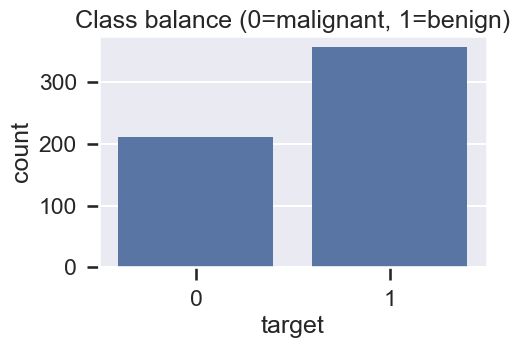

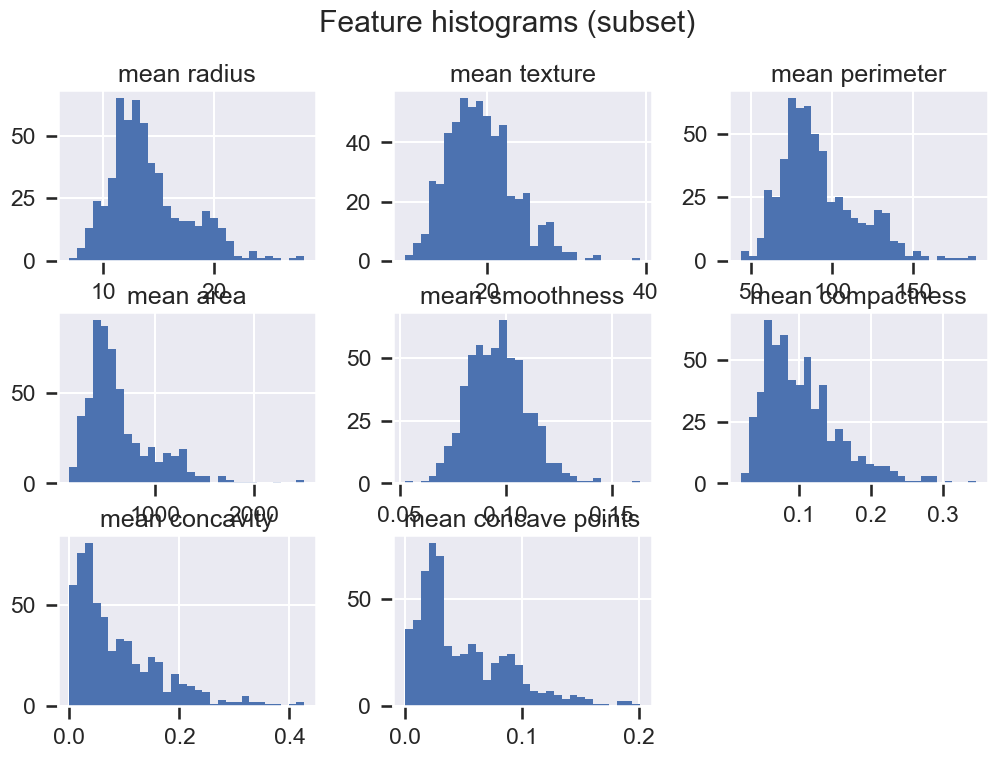

In [3]:
# Class balance
plt.figure(figsize=(5,3))
sns.countplot(x='target', data=df)
plt.title('Class balance (0=malignant, 1=benign)')
plt.show()

# Feature distributions (subset)
cols = [c for c in df.columns if c != 'target'][:8]
df[cols].hist(figsize=(12,8), bins=30)
plt.suptitle('Feature histograms (subset)')
plt.show()


## Baselines and pipelines

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

num_cols = X.columns.tolist()
prep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
ct = ColumnTransformer([('num', prep, num_cols)])

models = {
    'dummy': DummyClassifier(strategy='most_frequent'),
    'logreg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=SEED),
    'svc_rbf': SVC(kernel='rbf', probability=True, random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy'}

import pandas as pd
rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', ct), ('model', model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        'model': name,
        'roc_auc_mean': res['test_roc_auc'].mean(),
        'f1_mean': res['test_f1'].mean(),
        'acc_mean': res['test_accuracy'].mean(),
    })

display(pd.DataFrame(rows).sort_values('roc_auc_mean', ascending=False))


,model,roc_auc_mean,f1_mean,acc_mean
1,logreg,0.995975,0.984224,0.980220
2,svc_rbf,0.995562,0.975615,0.969231
0,dummy,0.500000,0.770270,0.626374


## Hyperparameter tuning (LogReg + SVC)

In [5]:
from sklearn.model_selection import GridSearchCV
import numpy as np

log_pipe = Pipeline([('prep', ct), ('model', LogisticRegression(max_iter=5000, solver='liblinear', random_state=SEED))])
log_grid = {
    'model__C': np.logspace(-3, 3, 13),
    'model__penalty': ['l1', 'l2'],
}
log_gs = GridSearchCV(log_pipe, log_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
log_gs.fit(X_train, y_train)
print('Best LogReg AUC:', log_gs.best_score_)
print('Best params:', log_gs.best_params_)

svc_pipe = Pipeline([('prep', ct), ('model', SVC(kernel='rbf', probability=True, random_state=SEED))])
svc_grid = {
    'model__C': np.logspace(-2, 2, 9),
    'model__gamma': np.logspace(-4, 0, 9),
}
svc_gs = GridSearchCV(svc_pipe, svc_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
svc_gs.fit(X_train, y_train)
print('Best SVC AUC:', svc_gs.best_score_)
print('Best params:', svc_gs.best_params_)


C:\Users\Olivier Robert\.openclaw\workspace\.venv-notebooks\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best LogReg AUC: 0.9959752321981423
Best params: {'model__C': np.float64(1.0), 'model__penalty': 'l2'}
Best SVC AUC: 0.9963880288957689
Best params: {'model__C': np.float64(10.0), 'model__gamma': np.float64(0.01)}


## Final evaluation + ROC/Confusion

Evaluate using threshold-free and thresholded metrics; visualize ROC + confusion matrix.

              precision    recall  f1-score   support

           0      0.976     0.976     0.976        42
           1      0.986     0.986     0.986        72

    accuracy                          0.982       114
   macro avg      0.981     0.981     0.981       114
weighted avg      0.982     0.982     0.982       114



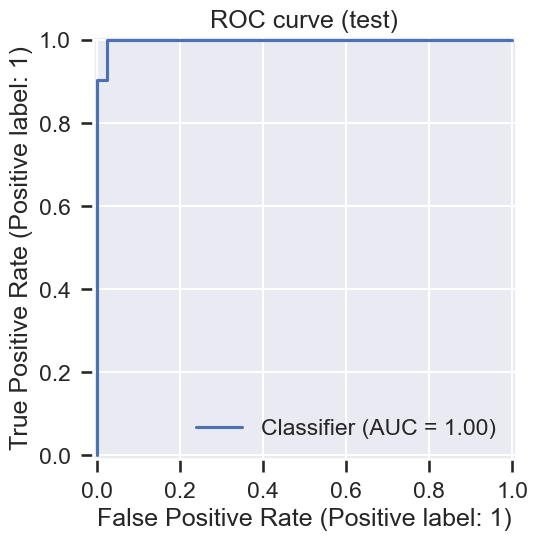

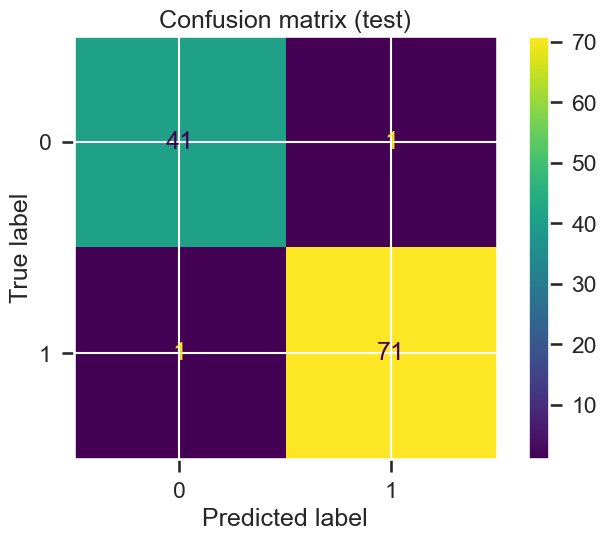

In [6]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, classification_report

best = svc_gs.best_estimator_
best.fit(X_train, y_train)
proba = best.predict_proba(X_test)[:, 1]
pred = best.predict(X_test)

print(classification_report(y_test, pred, digits=3))

RocCurveDisplay.from_predictions(y_test, proba)
plt.title('ROC curve (test)')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title('Confusion matrix (test)')
plt.show()
